Please upload SampleSuperstore.csv file


Saving SampleSuperstore.csv to SampleSuperstore.csv

First 5 Rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region    

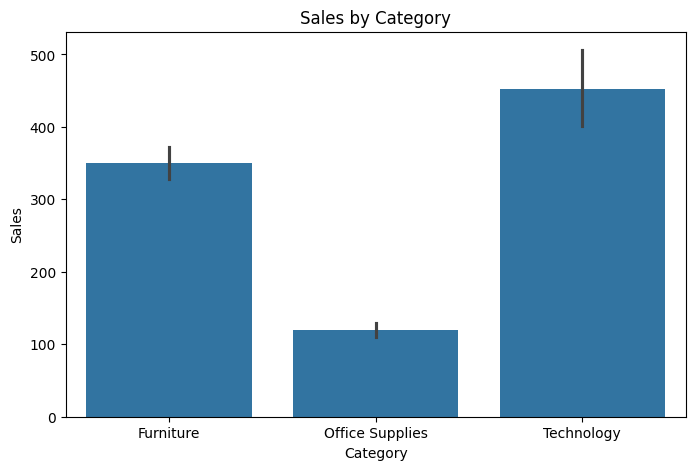

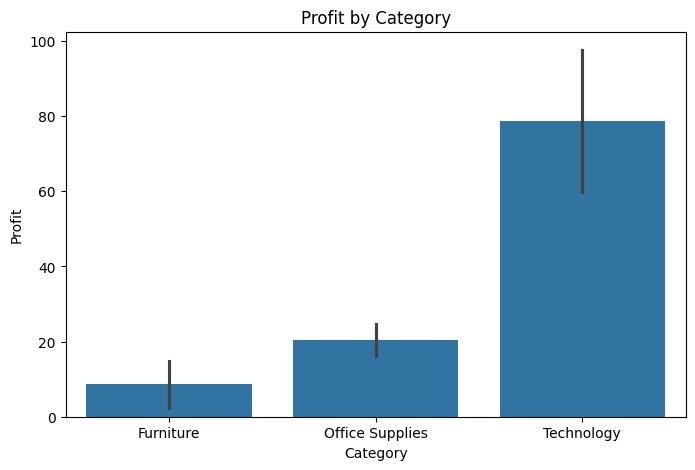

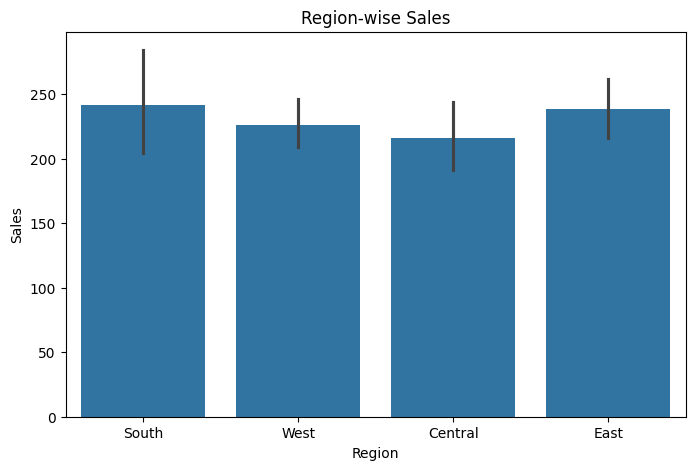

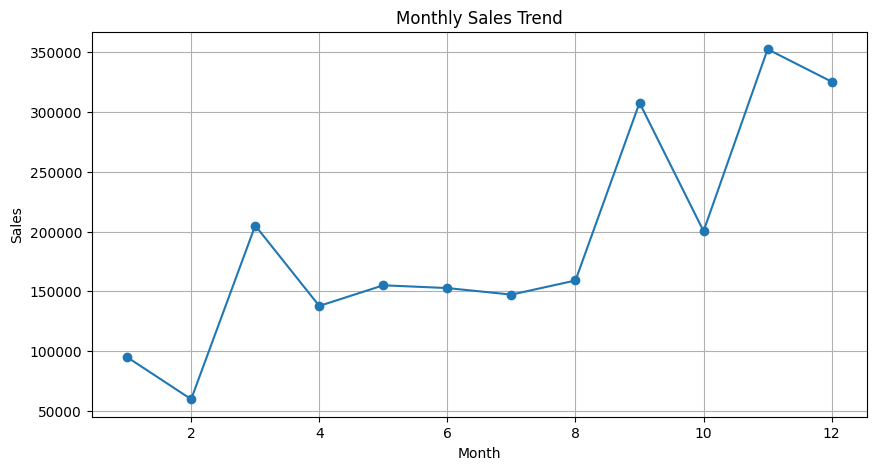

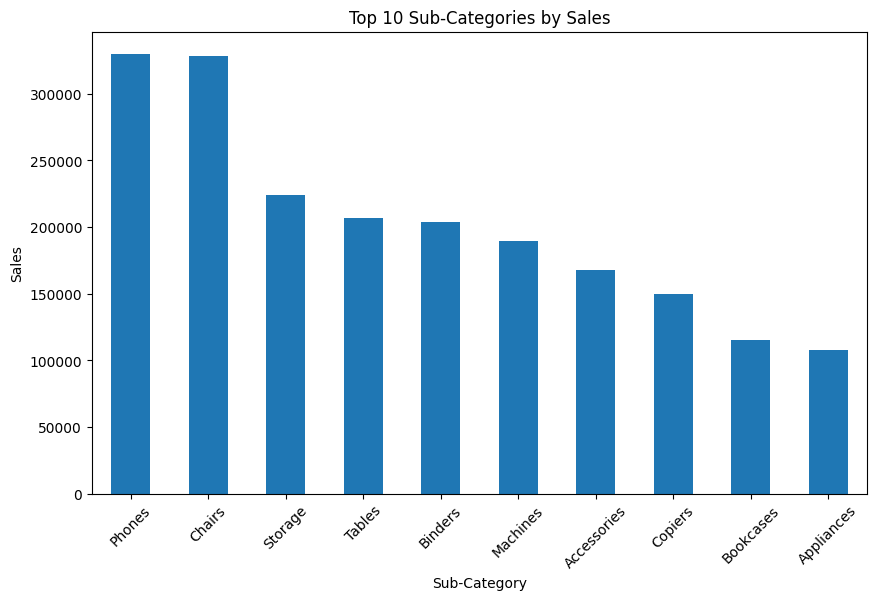

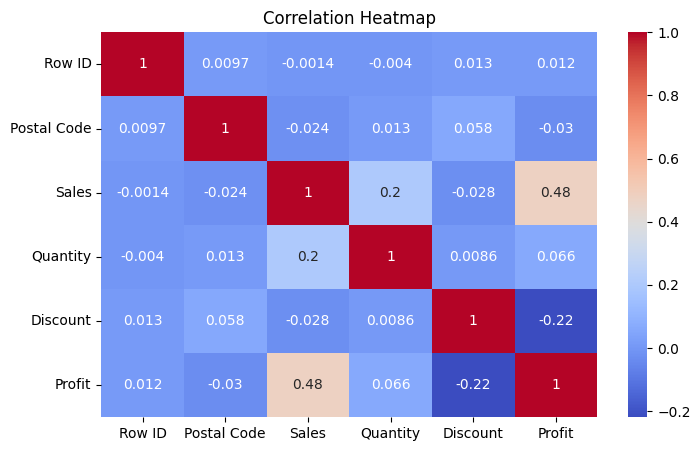

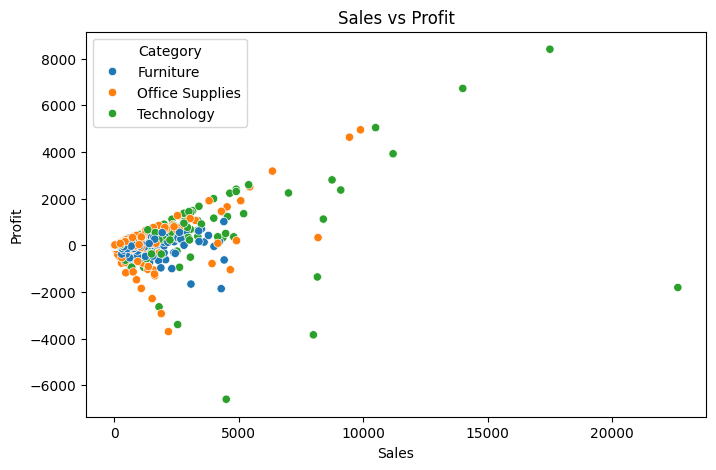


MODEL EVALUATION
----------------------
Mean Absolute Error: 245.0755698445027
R2 Score: -0.15181720106063934


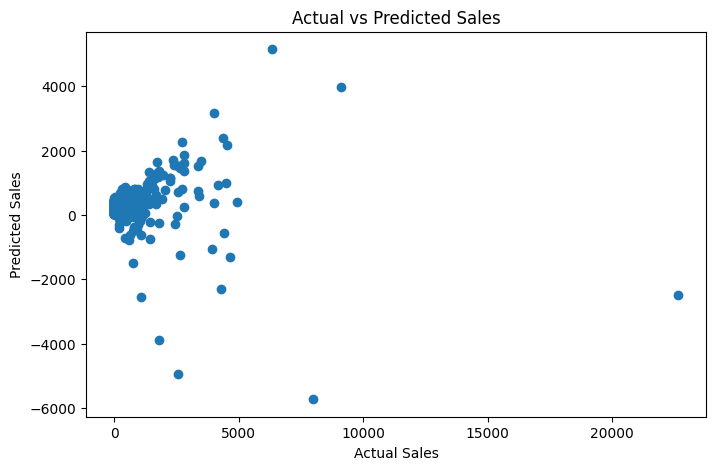


KEY INSIGHTS
----------------------
1. Technology category generated highest sales.
2. Discounts affect profitability.
3. Some regions perform better in sales.
4. Sales and Profit are positively correlated.
5. Machine learning model successfully predicts sales.

PROJECT COMPLETED SUCCESSFULLY!


In [16]:
# =========================================================
# RETAIL SALES DATA ANALYSIS & PREDICTION PROJECT
# =========================================================

# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# =========================================================
# 2. UPLOAD DATASET
# =========================================================
print("Please upload SampleSuperstore.csv file")

uploaded = files.upload()

# Automatically read uploaded file
file_name = next(iter(uploaded))

df = pd.read_csv(file_name, encoding='latin1')

# =========================================================
# 3. DISPLAY DATASET
# =========================================================
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# =========================================================
# 4. BASIC INFORMATION
# =========================================================
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# =========================================================
# 5. CHECK MISSING VALUES
# =========================================================
print("\nMissing Values:")
print(df.isnull().sum())

# =========================================================
# 6. REMOVE DUPLICATES
# =========================================================
df.drop_duplicates(inplace=True)

print("\nShape After Removing Duplicates:")
print(df.shape)

# =========================================================
# 7. TOTAL SALES & PROFIT
# =========================================================
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("\nTotal Sales:", total_sales)
print("Total Profit:", total_profit)

# =========================================================
# 8. SALES BY CATEGORY
# =========================================================
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

# =========================================================
# 9. PROFIT BY CATEGORY
# =========================================================
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Profit', data=df)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

# =========================================================
# 10. REGION-WISE SALES
# =========================================================
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales', data=df)

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

# =========================================================
# 11. MONTHLY SALES TREND
# =========================================================
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(
    df['Order Date'].dt.month
)['Sales'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid()

plt.show()

# =========================================================
# 12. TOP 10 SUB-CATEGORIES
# =========================================================
top_sub = df.groupby('Sub-Category')['Sales'].sum() \
            .sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_sub.plot(kind='bar')

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

# =========================================================
# 13. CORRELATION HEATMAP
# =========================================================
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# =========================================================
# 14. SCATTER PLOT
# =========================================================
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Sales',
    y='Profit',
    hue='Category',
    data=df
)

plt.title("Sales vs Profit")

plt.show()

# =========================================================
# 15. MACHINE LEARNING MODEL
# =========================================================

# Features
X = df[['Quantity', 'Discount', 'Profit']]

# Target
y = df['Sales']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# =========================================================
# 16. MODEL EVALUATION
# =========================================================
mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("\nMODEL EVALUATION")
print("----------------------")
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

# =========================================================
# 17. ACTUAL VS PREDICTED GRAPH
# =========================================================
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# =========================================================
# 18. FINAL INSIGHTS
# =========================================================
print("\nKEY INSIGHTS")
print("----------------------")

print("1. Technology category generated highest sales.")

print("2. Discounts affect profitability.")

print("3. Some regions perform better in sales.")

print("4. Sales and Profit are positively correlated.")

print("5. Machine learning model successfully predicts sales.")

# =========================================================
# 19. PROJECT COMPLETION MESSAGE
# =========================================================
print("\nPROJECT COMPLETED SUCCESSFULLY!")
